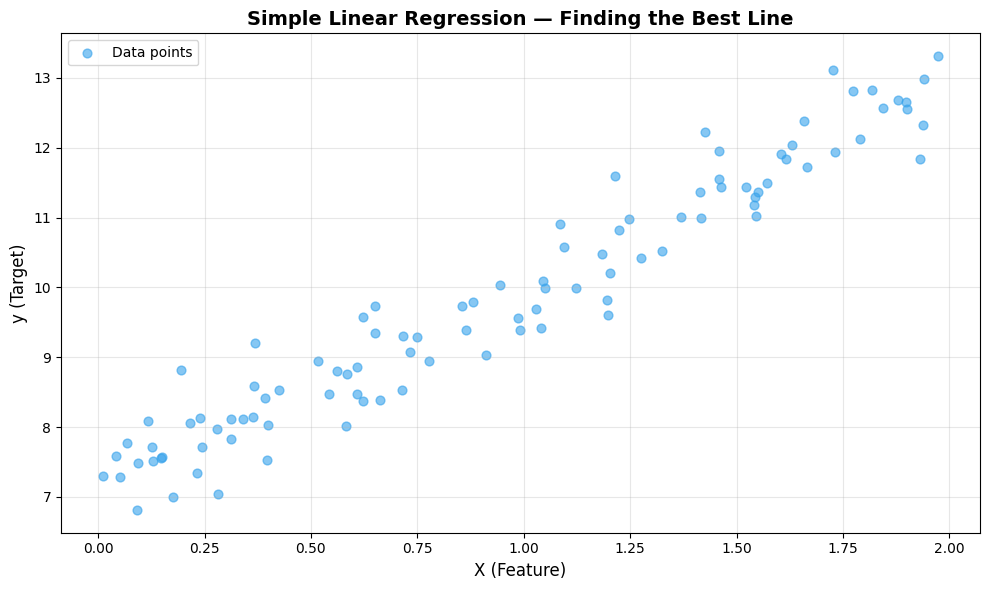

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Generate data: y = 3x + 7 + noise
np.random.seed(42)
X = 2 * np.random.rand(100)
y = 7 + 3 * X + np.random.randn(100) * 0.5

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(X, y, alpha=0.6, color='#36A2EB', s=40, label='Data points')
ax.set_xlabel('X (Feature)', fontsize=12)
ax.set_ylabel('y (Target)', fontsize=12)
ax.set_title('Simple Linear Regression — Finding the Best Line', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('simple_lr_data.png', dpi=150)
plt.show()

In [2]:
import numpy as np

# Generate data
np.random.seed(42)
X = 2 * np.random.rand(100)
y = 7 + 3 * X + np.random.randn(100) * 0.5

# Closed-form solution (by hand!)
x_mean = np.mean(X)
y_mean = np.mean(y)

# w = Cov(X,Y) / Var(X)
numerator = np.sum((X - x_mean) * (y - y_mean))
denominator = np.sum((X - x_mean) ** 2)
w = numerator / denominator

# b = y_mean - w * x_mean
b = y_mean - w * x_mean

print(f"Closed-form solution:")
print(f"  w = {w:.4f} (true: 3.0)")
print(f"  b = {b:.4f} (true: 7.0)")

Closed-form solution:
  w = 2.8851 (true: 3.0)
  b = 7.1075 (true: 7.0)


In [3]:
import numpy as np

# Normal Equation implementation
np.random.seed(42)
X = 2 * np.random.rand(100)
y = 7 + 3 * X + np.random.randn(100) * 0.5

# Add bias column (column of 1s)
X_b = np.c_[np.ones(len(X)), X]  # Shape: (100, 2)

# Normal equation: θ = (X^T X)^(-1) X^T y
theta = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

print(f"Normal equation solution:")
print(f"  Intercept (b): {theta[0]:.4f} (true: 7.0)")
print(f"  Slope (w):     {theta[1]:.4f} (true: 3.0)")

Normal equation solution:
  Intercept (b): 7.1075 (true: 7.0)
  Slope (w):     2.8851 (true: 3.0)


Gradient descent solution:
  Intercept: 7.1075
  Slope:     2.8851


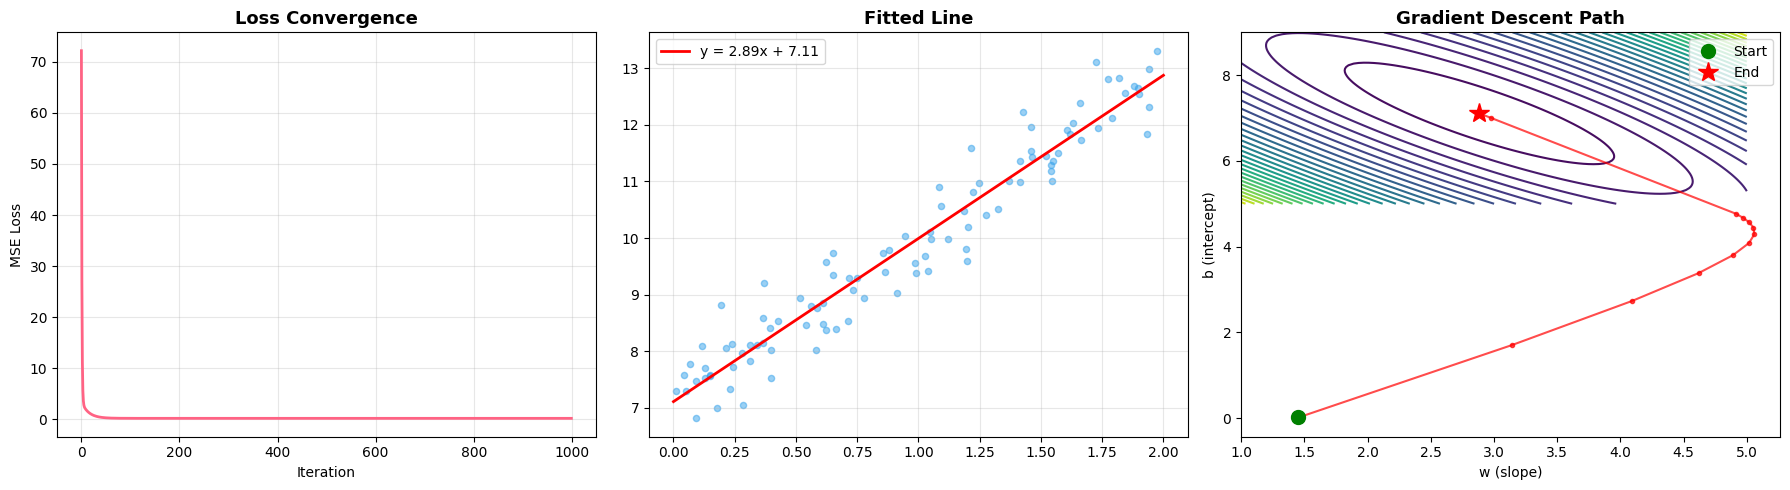

In [4]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
X = 2 * np.random.rand(100)
y = 7 + 3 * X + np.random.randn(100) * 0.5

# Add bias column
X_b = np.c_[np.ones(len(X)), X]
n = len(X)

# Gradient Descent
learning_rate = 0.1
n_iterations = 1000
theta = np.random.randn(2)  # Random initialization

losses = []
theta_history = [theta.copy()]

for iteration in range(n_iterations):
    # Forward pass
    y_pred = X_b @ theta
    
    # Compute loss (MSE)
    loss = np.mean((y - y_pred) ** 2)
    losses.append(loss)
    
    # Compute gradients
    gradients = (2/n) * X_b.T @ (y_pred - y)
    
    # Update parameters
    theta = theta - learning_rate * gradients
    
    if iteration < 10 or iteration % 100 == 0:
        theta_history.append(theta.copy())

print(f"Gradient descent solution:")
print(f"  Intercept: {theta[0]:.4f}")
print(f"  Slope:     {theta[1]:.4f}")

# Visualize convergence
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss curve
axes[0].plot(losses, color='#FF6384', linewidth=2)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Loss Convergence', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Data with learned line
axes[1].scatter(X, y, alpha=0.5, s=20, color='#36A2EB')
X_line = np.linspace(0, 2, 100)
axes[1].plot(X_line, theta[0] + theta[1] * X_line, 'r-', linewidth=2,
             label=f'y = {theta[1]:.2f}x + {theta[0]:.2f}')
axes[1].set_title('Fitted Line', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Gradient descent path in parameter space
thetas = np.array(theta_history)
w_range = np.linspace(1, 5, 100)
b_range = np.linspace(5, 9, 100)
W, B = np.meshgrid(w_range, b_range)
Z = np.zeros_like(W)
for i in range(len(w_range)):
    for j in range(len(b_range)):
        y_pred = B[j, i] + W[j, i] * X
        Z[j, i] = np.mean((y - y_pred) ** 2)

axes[2].contour(W, B, Z, levels=30, cmap='viridis')
axes[2].plot(thetas[:, 1], thetas[:, 0], 'ro-', markersize=3, alpha=0.7)
axes[2].plot(thetas[0, 1], thetas[0, 0], 'go', markersize=10, label='Start')
axes[2].plot(thetas[-1, 1], thetas[-1, 0], 'r*', markersize=15, label='End')
axes[2].set_xlabel('w (slope)')
axes[2].set_ylabel('b (intercept)')
axes[2].set_title('Gradient Descent Path', fontsize=13, fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.savefig('gradient_descent_lr.png', dpi=150)
plt.show()

In [5]:
import numpy as np

np.random.seed(42)
X = 2 * np.random.rand(1000)
y = 7 + 3 * X + np.random.randn(1000) * 0.5
X_b = np.c_[np.ones(len(X)), X]
n = len(X)

# Stochastic Gradient Descent (SGD)
theta_sgd = np.random.randn(2)
learning_rate = 0.01
n_epochs = 50

for epoch in range(n_epochs):
    # Shuffle data each epoch
    indices = np.random.permutation(n)
    X_shuffled = X_b[indices]
    y_shuffled = y[indices]
    
    for i in range(n):
        xi = X_shuffled[i:i+1]  # Single sample
        yi = y_shuffled[i:i+1]
        gradient = 2 * xi.T @ (xi @ theta_sgd - yi)
        theta_sgd = theta_sgd - learning_rate * gradient.flatten()

print(f"SGD solution: w={theta_sgd[1]:.4f}, b={theta_sgd[0]:.4f}")

# Mini-Batch Gradient Descent
theta_mb = np.random.randn(2)
batch_size = 32

for epoch in range(n_epochs):
    indices = np.random.permutation(n)
    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)
        idx = indices[start:end]
        xi = X_b[idx]
        yi = y[idx]
        gradient = (2/len(idx)) * xi.T @ (xi @ theta_mb - yi)
        theta_mb = theta_mb - learning_rate * gradient

print(f"Mini-batch solution: w={theta_mb[1]:.4f}, b={theta_mb[0]:.4f}")

SGD solution: w=2.9211, b=7.0219
Mini-batch solution: w=2.9846, b=7.0760


Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Shape: (20640, 8)

         MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
count  20640.00  20640.00  20640.00   20640.00    20640.00  20640.00   
mean       3.87     28.64      5.43       1.10     1425.48      3.07   
std        1.90     12.59      2.47       0.47     1132.46     10.39   
min        0.50      1.00      0.85       0.33        3.00      0.69   
25%        2.56     18.00      4.44       1.01      787.00      2.43   
50%        3.53     29.00      5.23       1.05     1166.00      2.82   
75%        4.74     37.00      6.05       1.10     1725.00      3.28   
max       15.00     52.00    141.91      34.07    35682.00   1243.33   

       Latitude  Longitude  
count  20640.00   20640.00  
mean      35.63    -119.57  
std        2.14       2.00  
min       32.54    -124.35  
25%       33.93    -121.80  
50%       34.26    -118.49  
75%       37.71    -

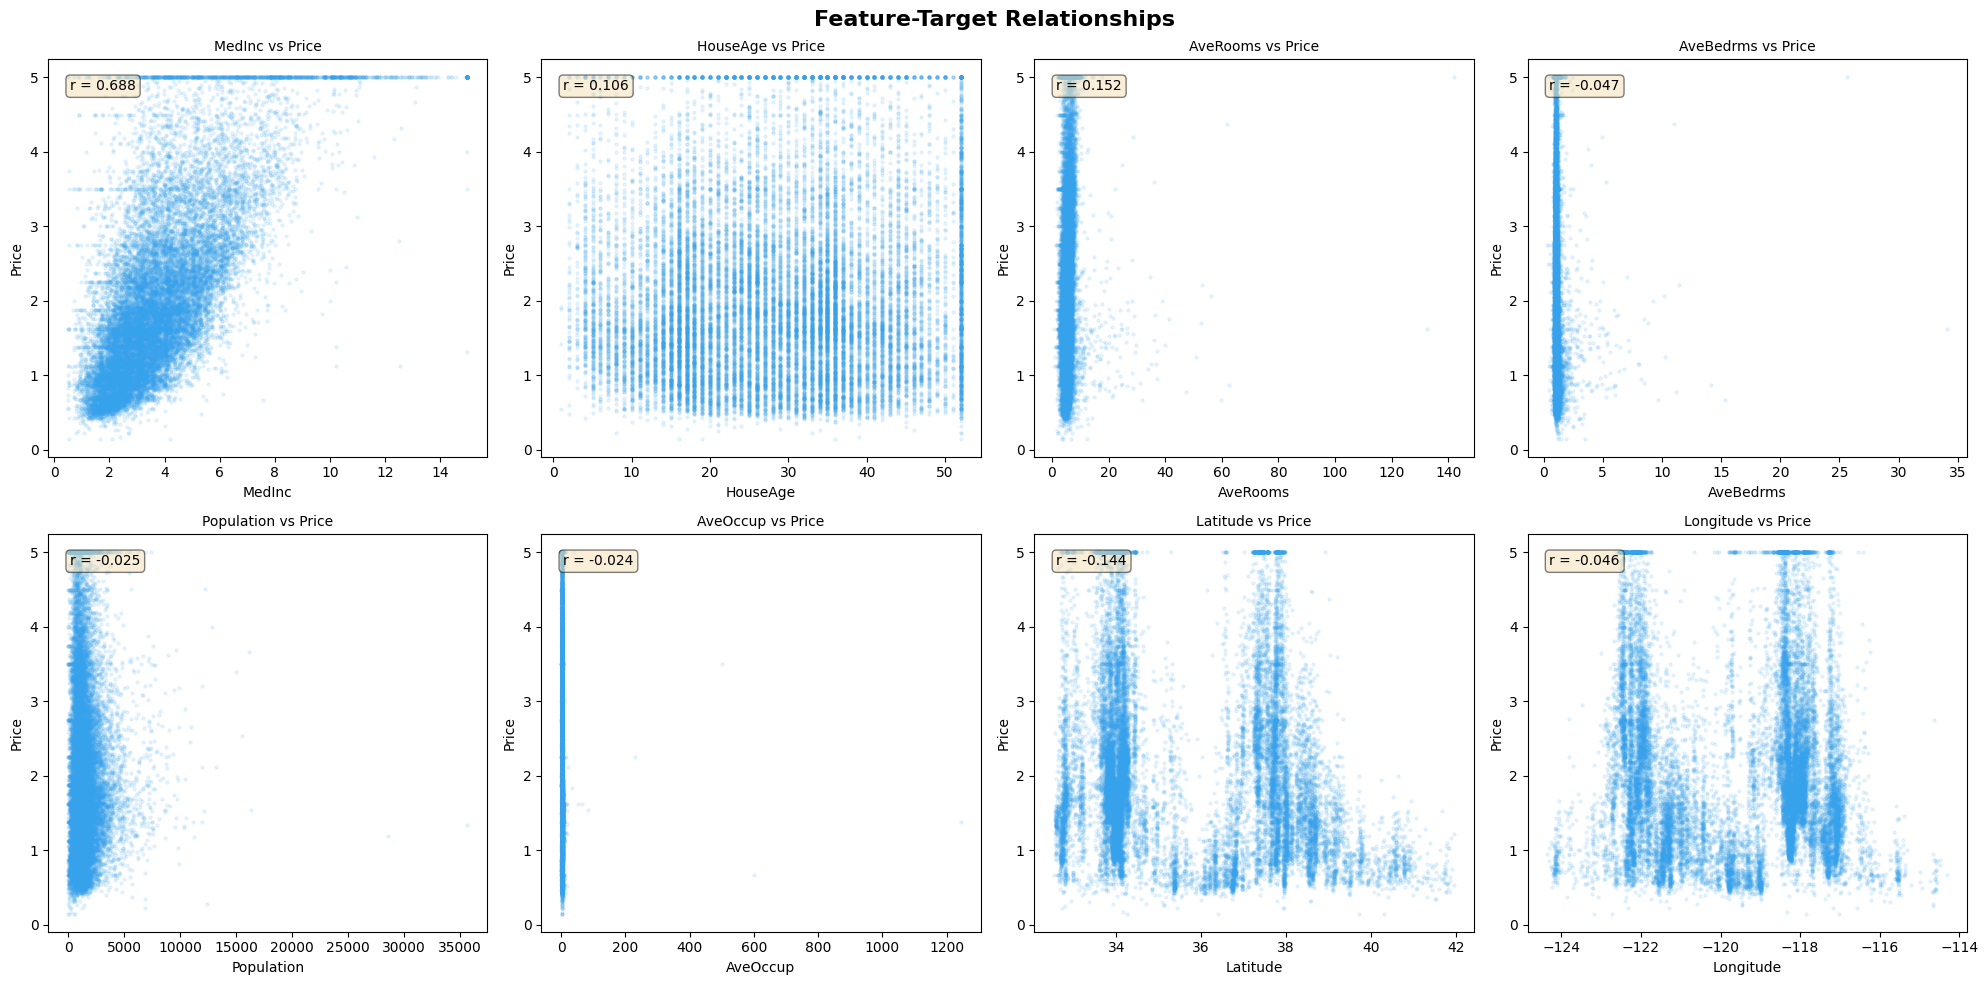

In [6]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
import matplotlib.pyplot as plt

# Load California Housing dataset
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target

print(f"Features: {list(X.columns)}")
print(f"Shape: {X.shape}")
print(f"\n{X.describe().round(2)}")

# Visualize feature-target relationships
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for i, (ax, col) in enumerate(zip(axes.flat, X.columns)):
    ax.scatter(X[col], y, alpha=0.1, s=5, color='#36A2EB')
    ax.set_xlabel(col)
    ax.set_ylabel('Price')
    ax.set_title(f'{col} vs Price', fontsize=10)
    
    # Add correlation
    corr = np.corrcoef(X[col], y)[0, 1]
    ax.text(0.05, 0.95, f'r = {corr:.3f}', transform=ax.transAxes,
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Feature-Target Relationships', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('multiple_lr_features.png', dpi=150)
plt.show()

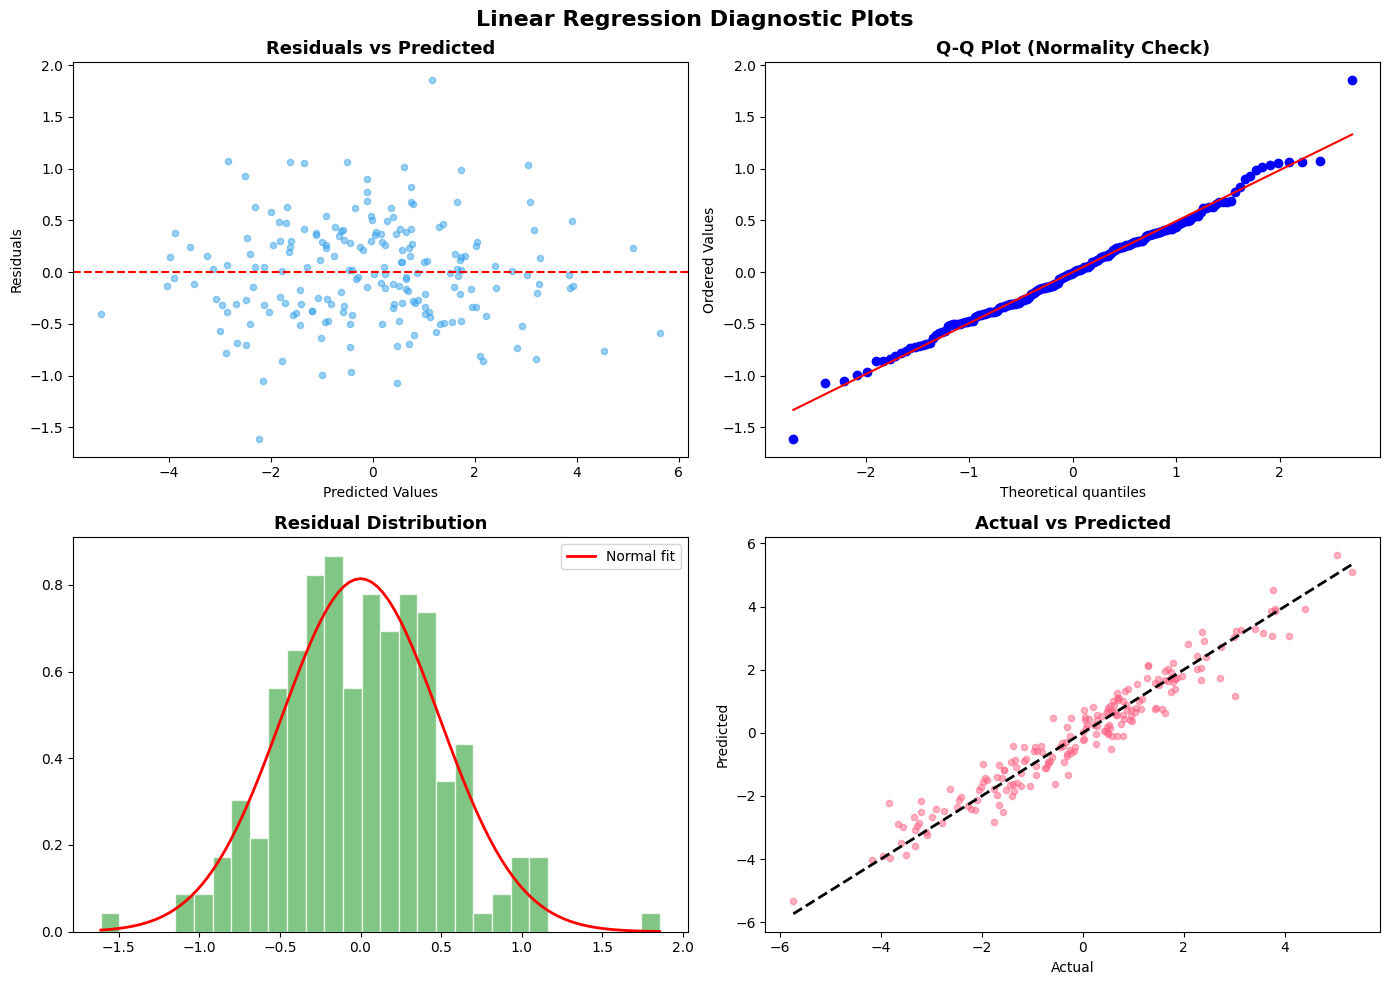

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy import stats

np.random.seed(42)
X = np.random.randn(200, 1)
y = 2 * X.ravel() + np.random.randn(200) * 0.5

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
residuals = y - y_pred

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuals vs Predicted (check linearity + homoscedasticity)
axes[0, 0].scatter(y_pred, residuals, alpha=0.5, s=20, color='#36A2EB')
axes[0, 0].axhline(y=0, color='red', linestyle='--')
axes[0, 0].set_xlabel('Predicted Values')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('Residuals vs Predicted', fontsize=13, fontweight='bold')

# 2. Q-Q Plot (check normality of residuals)
stats.probplot(residuals, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot (Normality Check)', fontsize=13, fontweight='bold')

# 3. Histogram of residuals
axes[1, 0].hist(residuals, bins=30, density=True, color='#4CAF50', edgecolor='white', alpha=0.7)
x_norm = np.linspace(residuals.min(), residuals.max(), 100)
axes[1, 0].plot(x_norm, stats.norm.pdf(x_norm, residuals.mean(), residuals.std()),
                'r-', linewidth=2, label='Normal fit')
axes[1, 0].set_title('Residual Distribution', fontsize=13, fontweight='bold')
axes[1, 0].legend()

# 4. Actual vs Predicted
axes[1, 1].scatter(y, y_pred, alpha=0.5, s=20, color='#FF6384')
axes[1, 1].plot([y.min(), y.max()], [y.min(), y.max()], 'k--', linewidth=2)
axes[1, 1].set_xlabel('Actual')
axes[1, 1].set_ylabel('Predicted')
axes[1, 1].set_title('Actual vs Predicted', fontsize=13, fontweight='bold')

plt.suptitle('Linear Regression Diagnostic Plots', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('lr_diagnostics.png', dpi=150)
plt.show()

In [8]:
import numpy as np

class LinearRegressionFromScratch:
    """Linear Regression using Gradient Descent — built from scratch."""
    
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.losses = []
    
    def fit(self, X, y):
        n_samples, n_features = X.shape
        
        # Initialize parameters
        self.weights = np.zeros(n_features)
        self.bias = 0
        self.losses = []
        
        for i in range(self.n_iterations):
            # Forward pass
            y_pred = X @ self.weights + self.bias
            
            # Compute loss (MSE)
            loss = np.mean((y - y_pred) ** 2)
            self.losses.append(loss)
            
            # Compute gradients
            dw = -(2/n_samples) * X.T @ (y - y_pred)
            db = -(2/n_samples) * np.sum(y - y_pred)
            
            # Update parameters
            self.weights -= self.lr * dw
            self.bias -= self.lr * db
        
        return self
    
    def predict(self, X):
        return X @ self.weights + self.bias
    
    def score(self, X, y):
        """R² score."""
        y_pred = self.predict(X)
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        return 1 - ss_res / ss_tot

# Test our implementation
np.random.seed(42)
X = np.random.randn(200, 3)
true_weights = np.array([2, -1, 0.5])
y = X @ true_weights + 3 + np.random.randn(200) * 0.3

# Our model
model = LinearRegressionFromScratch(learning_rate=0.01, n_iterations=1000)
model.fit(X, y)

print(f"True weights:    {true_weights}")
print(f"Learned weights: {model.weights.round(4)}")
print(f"True bias:       3.0")
print(f"Learned bias:    {model.bias:.4f}")
print(f"R² score:        {model.score(X, y):.6f}")

True weights:    [ 2.  -1.   0.5]
Learned weights: [ 1.9928 -0.9723  0.5356]
True bias:       3.0
Learned bias:    3.0056
R² score:        0.978914


LINEAR REGRESSION RESULTS
R² Score:          0.5758
MSE:               0.5559
RMSE:              0.7456
MAE:               0.5332

Coefficients:
         Latitude:  -0.8969
        Longitude:  -0.8698
           MedInc:   0.8544
        AveBedrms:   0.3393
         AveRooms:  -0.2944
         HouseAge:   0.1225
         AveOccup:  -0.0408
       Population:  -0.0023
        Intercept:   2.0719


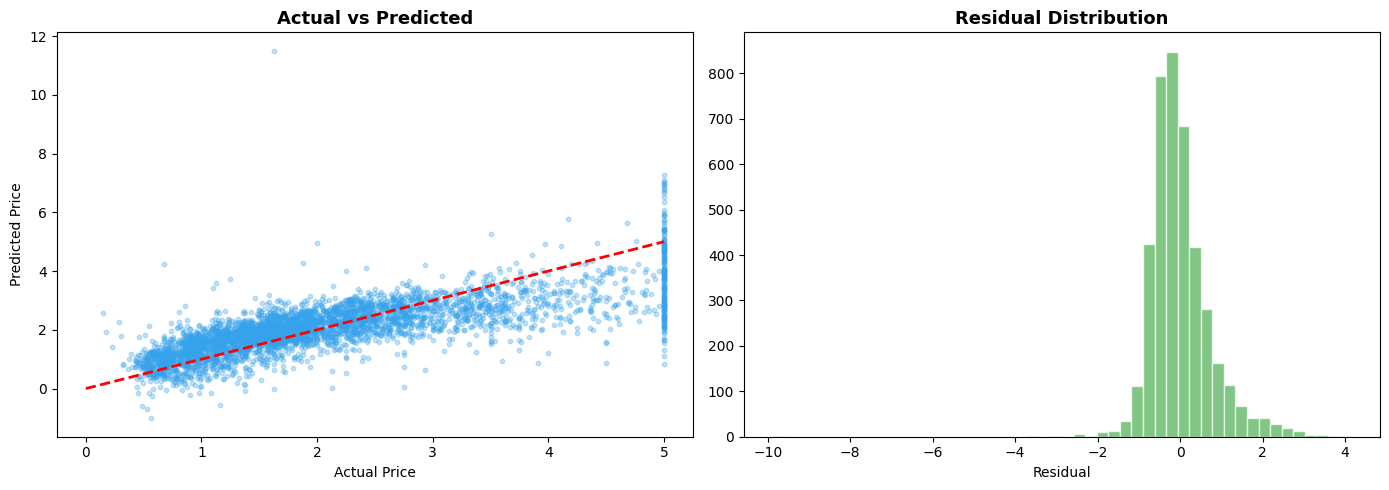

In [9]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.datasets import fetch_california_housing
import matplotlib.pyplot as plt

# Load data
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Predict
y_pred = model.predict(X_test_scaled)

# Evaluate
print("=" * 50)
print("LINEAR REGRESSION RESULTS")
print("=" * 50)
print(f"R² Score:          {r2_score(y_test, y_pred):.4f}")
print(f"MSE:               {mean_squared_error(y_test, y_pred):.4f}")
print(f"RMSE:              {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"MAE:               {mean_absolute_error(y_test, y_pred):.4f}")

# Coefficients
print(f"\nCoefficients:")
for name, coef in sorted(zip(housing.feature_names, model.coef_), key=lambda x: abs(x[1]), reverse=True):
    print(f"  {name:>15}: {coef:>8.4f}")
print(f"  {'Intercept':>15}: {model.intercept_:>8.4f}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred, alpha=0.3, s=10, color='#36A2EB')
axes[0].plot([0, 5], [0, 5], 'r--', linewidth=2)
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')
axes[0].set_title('Actual vs Predicted', fontsize=13, fontweight='bold')

residuals = y_test - y_pred
axes[1].hist(residuals, bins=50, color='#4CAF50', edgecolor='white', alpha=0.7)
axes[1].set_title('Residual Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Residual')

plt.tight_layout()
plt.savefig('sklearn_lr.png', dpi=150)
plt.show()